# Trajectory and velocity analysis of scRNAseq COLON data 

This is one in the series of notebooks presenting the data analysis done in the study "Widespread epithelial dedifferentiation in patients with ulcerative colitis". It is also intended as a tutorial in scRNAseq analysis. Please refer to the REAMDE file for the description of different parts of the tutorial and how to follow it.  

## Part 4. Clustering and annotating celltypes

This is the fourth part of the guide in which we perform clustering and then annotate the clusters with known celltypes. In the annotation process we use the information from differential expression analysis and expression of known markers. 

### Healthy dataset

This notebook shows the pipeline done on the "Healthy dataset" (see study for details regarding samples constituting the dataset). Here I am explaining the procedure step by step, so hopefully one can repeat it on their own data. In this repository there are also notebooks showing the same pipeline for other datasets from the study. I am not repeating the descriptions in those, so please always refer to the "Healthy dataset" notebooks while following the tutorial. 

Here I am working on 4 samples which I want to merge together into one condition - Healthy. You need to adjust the code accordingly to the number of samples/conditions you're working on. 

#### 0. Imports and settings

In [1]:
import scanpy as sc
import scvelo as scv
import numpy as np

#### 1. Load data

First lets load the file we have prepared in the previous part of the tutorial.

In [2]:
adata = sc.read('healthy_dr.h5ad')

#### 2. Clustering

We will use scanpy's function `tl.leiden` to partion the data into clusters. Again, we can use the plotting function in tandem to quickly inspect the results. Resolution is a parameter that determines how granular the clustering should be, with higher resolution resolving in larger amount of smaller clusters.   

In [3]:
scv.settings.set_figure_params('scvelo', dpi=75, vector_friendly=True, figsize=[6,6])

In [4]:
sc.tl.leiden(adata, resolution=1)

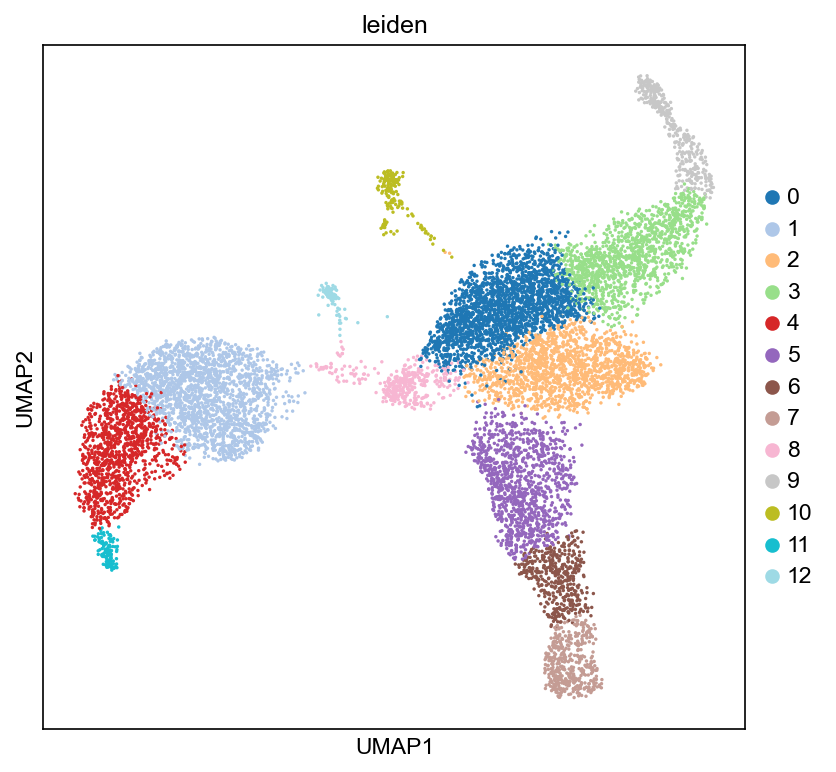

In [5]:
sc.pl.umap(adata, color='leiden', palette='tab20')

By increasing the resolution we can try to look for more complicated patterns in cell distribution. 

In [6]:
sc.tl.leiden(adata, resolution=6, key_added='SubLeiden')

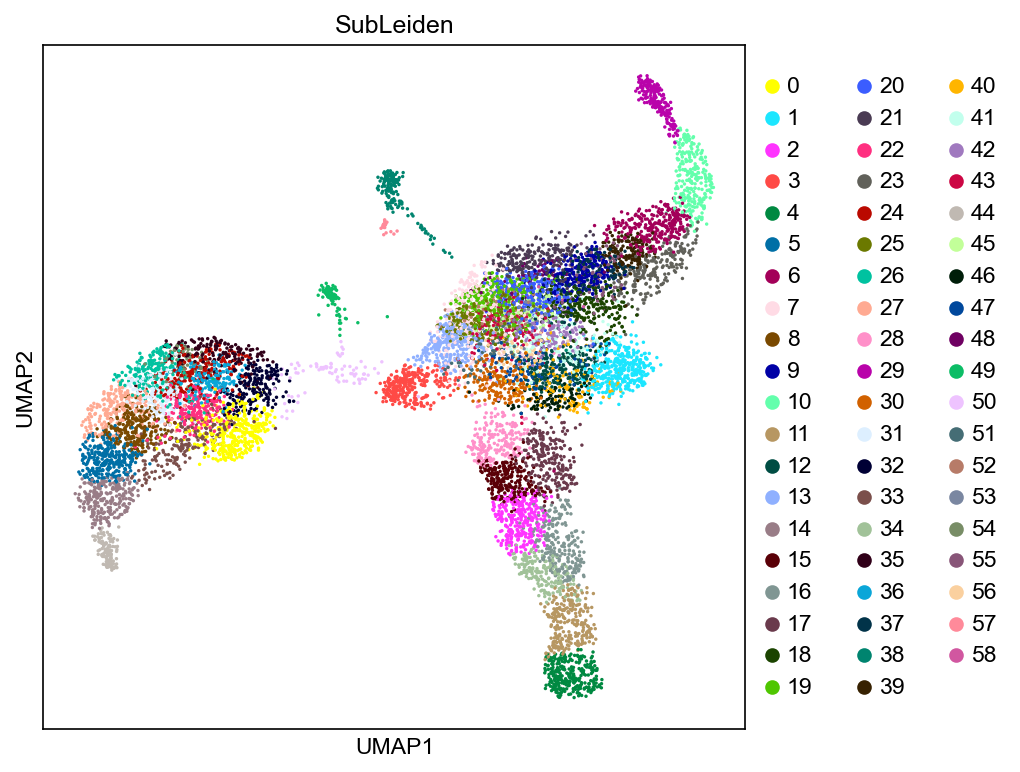

In [7]:
sc.pl.umap(adata, color='SubLeiden')

#### 3. Differential expression and gene markers

Next, let's look at the Differential Expression (DE) results to see which genes mark the clusters. We can compare those genes with out knowledge about cell types we would expect to detect in our dataset. This also allows us to see whether the clusters express enough unique genes to be classified as a separate one celltype. If there are genes strongly expressed in the cluster, but only in a part of it, then the cluster may have to be divided. If there are the same genes expressed over multiple clusters then those clusters may have to be joined. 

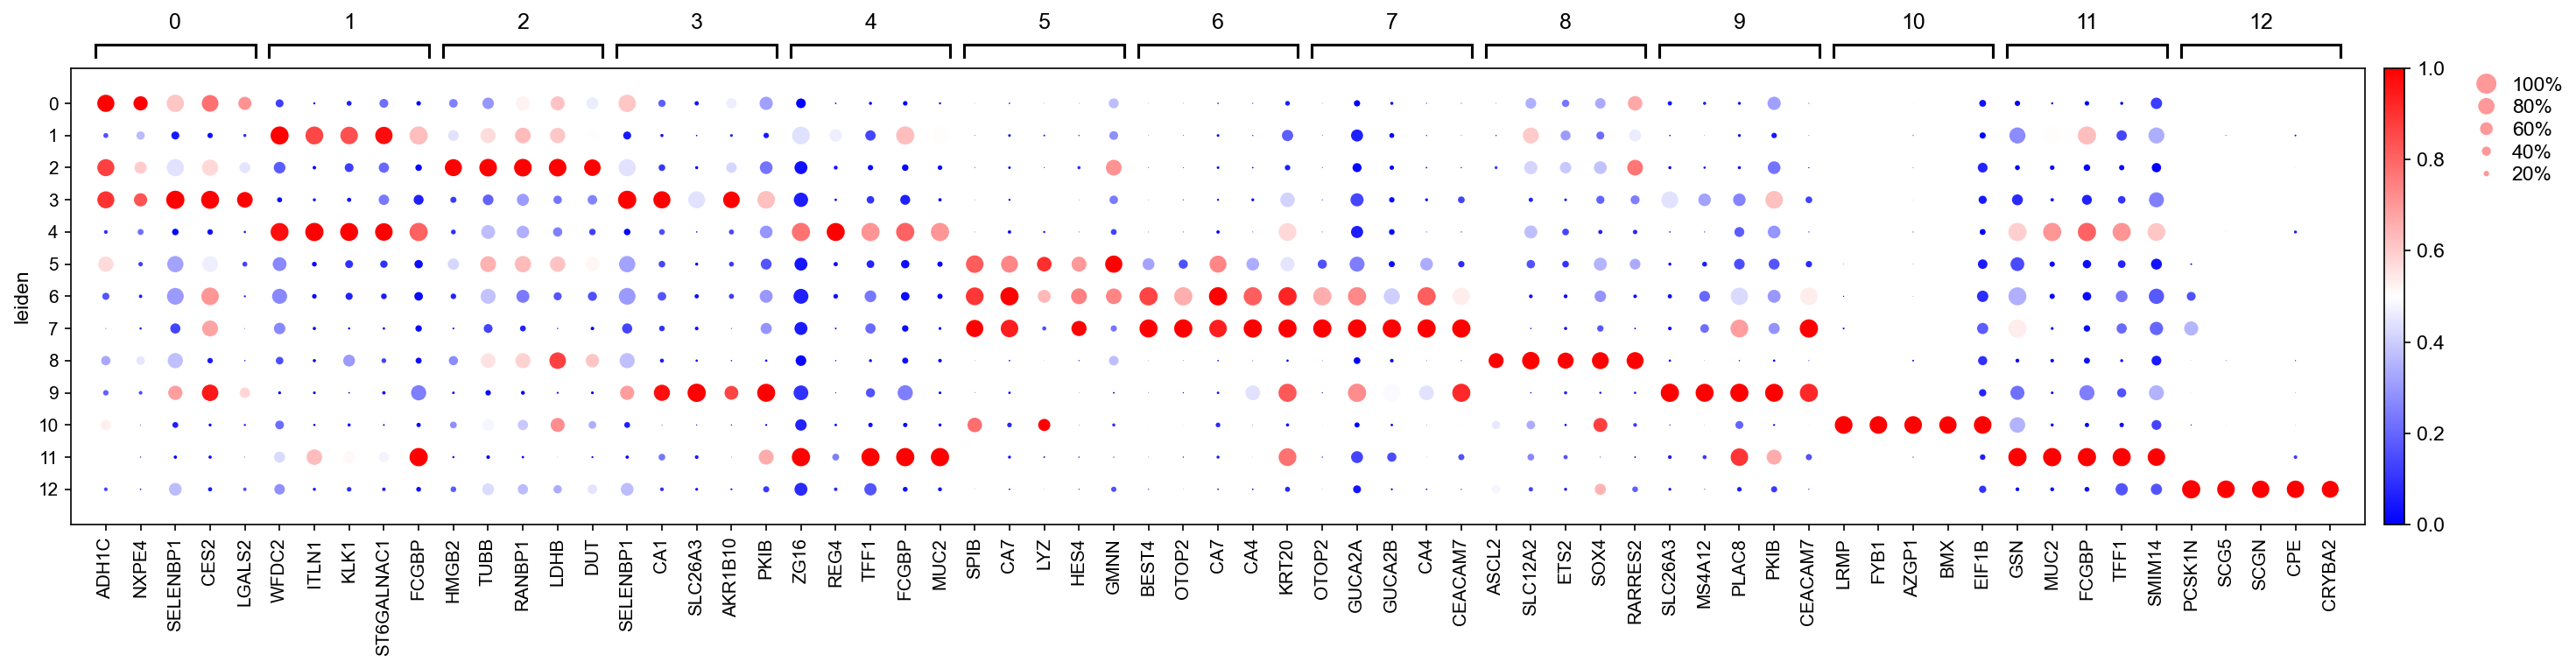

In [8]:
# Rank DEGs per leiden clustering
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')
# Filter out genes based on expression specificity and fold changen
sc.tl.filter_rank_genes_groups(adata, min_in_group_fraction=0.25, 
                               max_out_group_fraction=0.75, min_fold_change=1.5)
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5, key='rank_genes_groups_filtered', 
                                standard_scale='var', color_map='bwr', dendrogram=False)

We test the differential expression comparing genes expressed in each leiden clusters to the rest of the cells. We are using the default method (`wilcoxon`), so the Wilcoxon rank-sum test, also called the Mann-Whitney *U* test. Before plotting the results we filter the genes. This is to get rid off the many genes that are not expressed specifically enough in the cluster in question. When plotting we put the expression on a 0 to 1 scale (with `standard_scale='var'`) to mitigate the differences in the base level of expression between different genes.

By changing `groupby='leiden'` to `groupby='SubLeiden'` you can also look at DEGs in the smaller clusters (I'm not showing it here due to the size of the image). By adding a parameter `save='filename'` you can save the image to file to be able to easier look through it on your computer.

Finally, we can also plot expression of known marker genes and see how does it align with the leiden partitioning. 

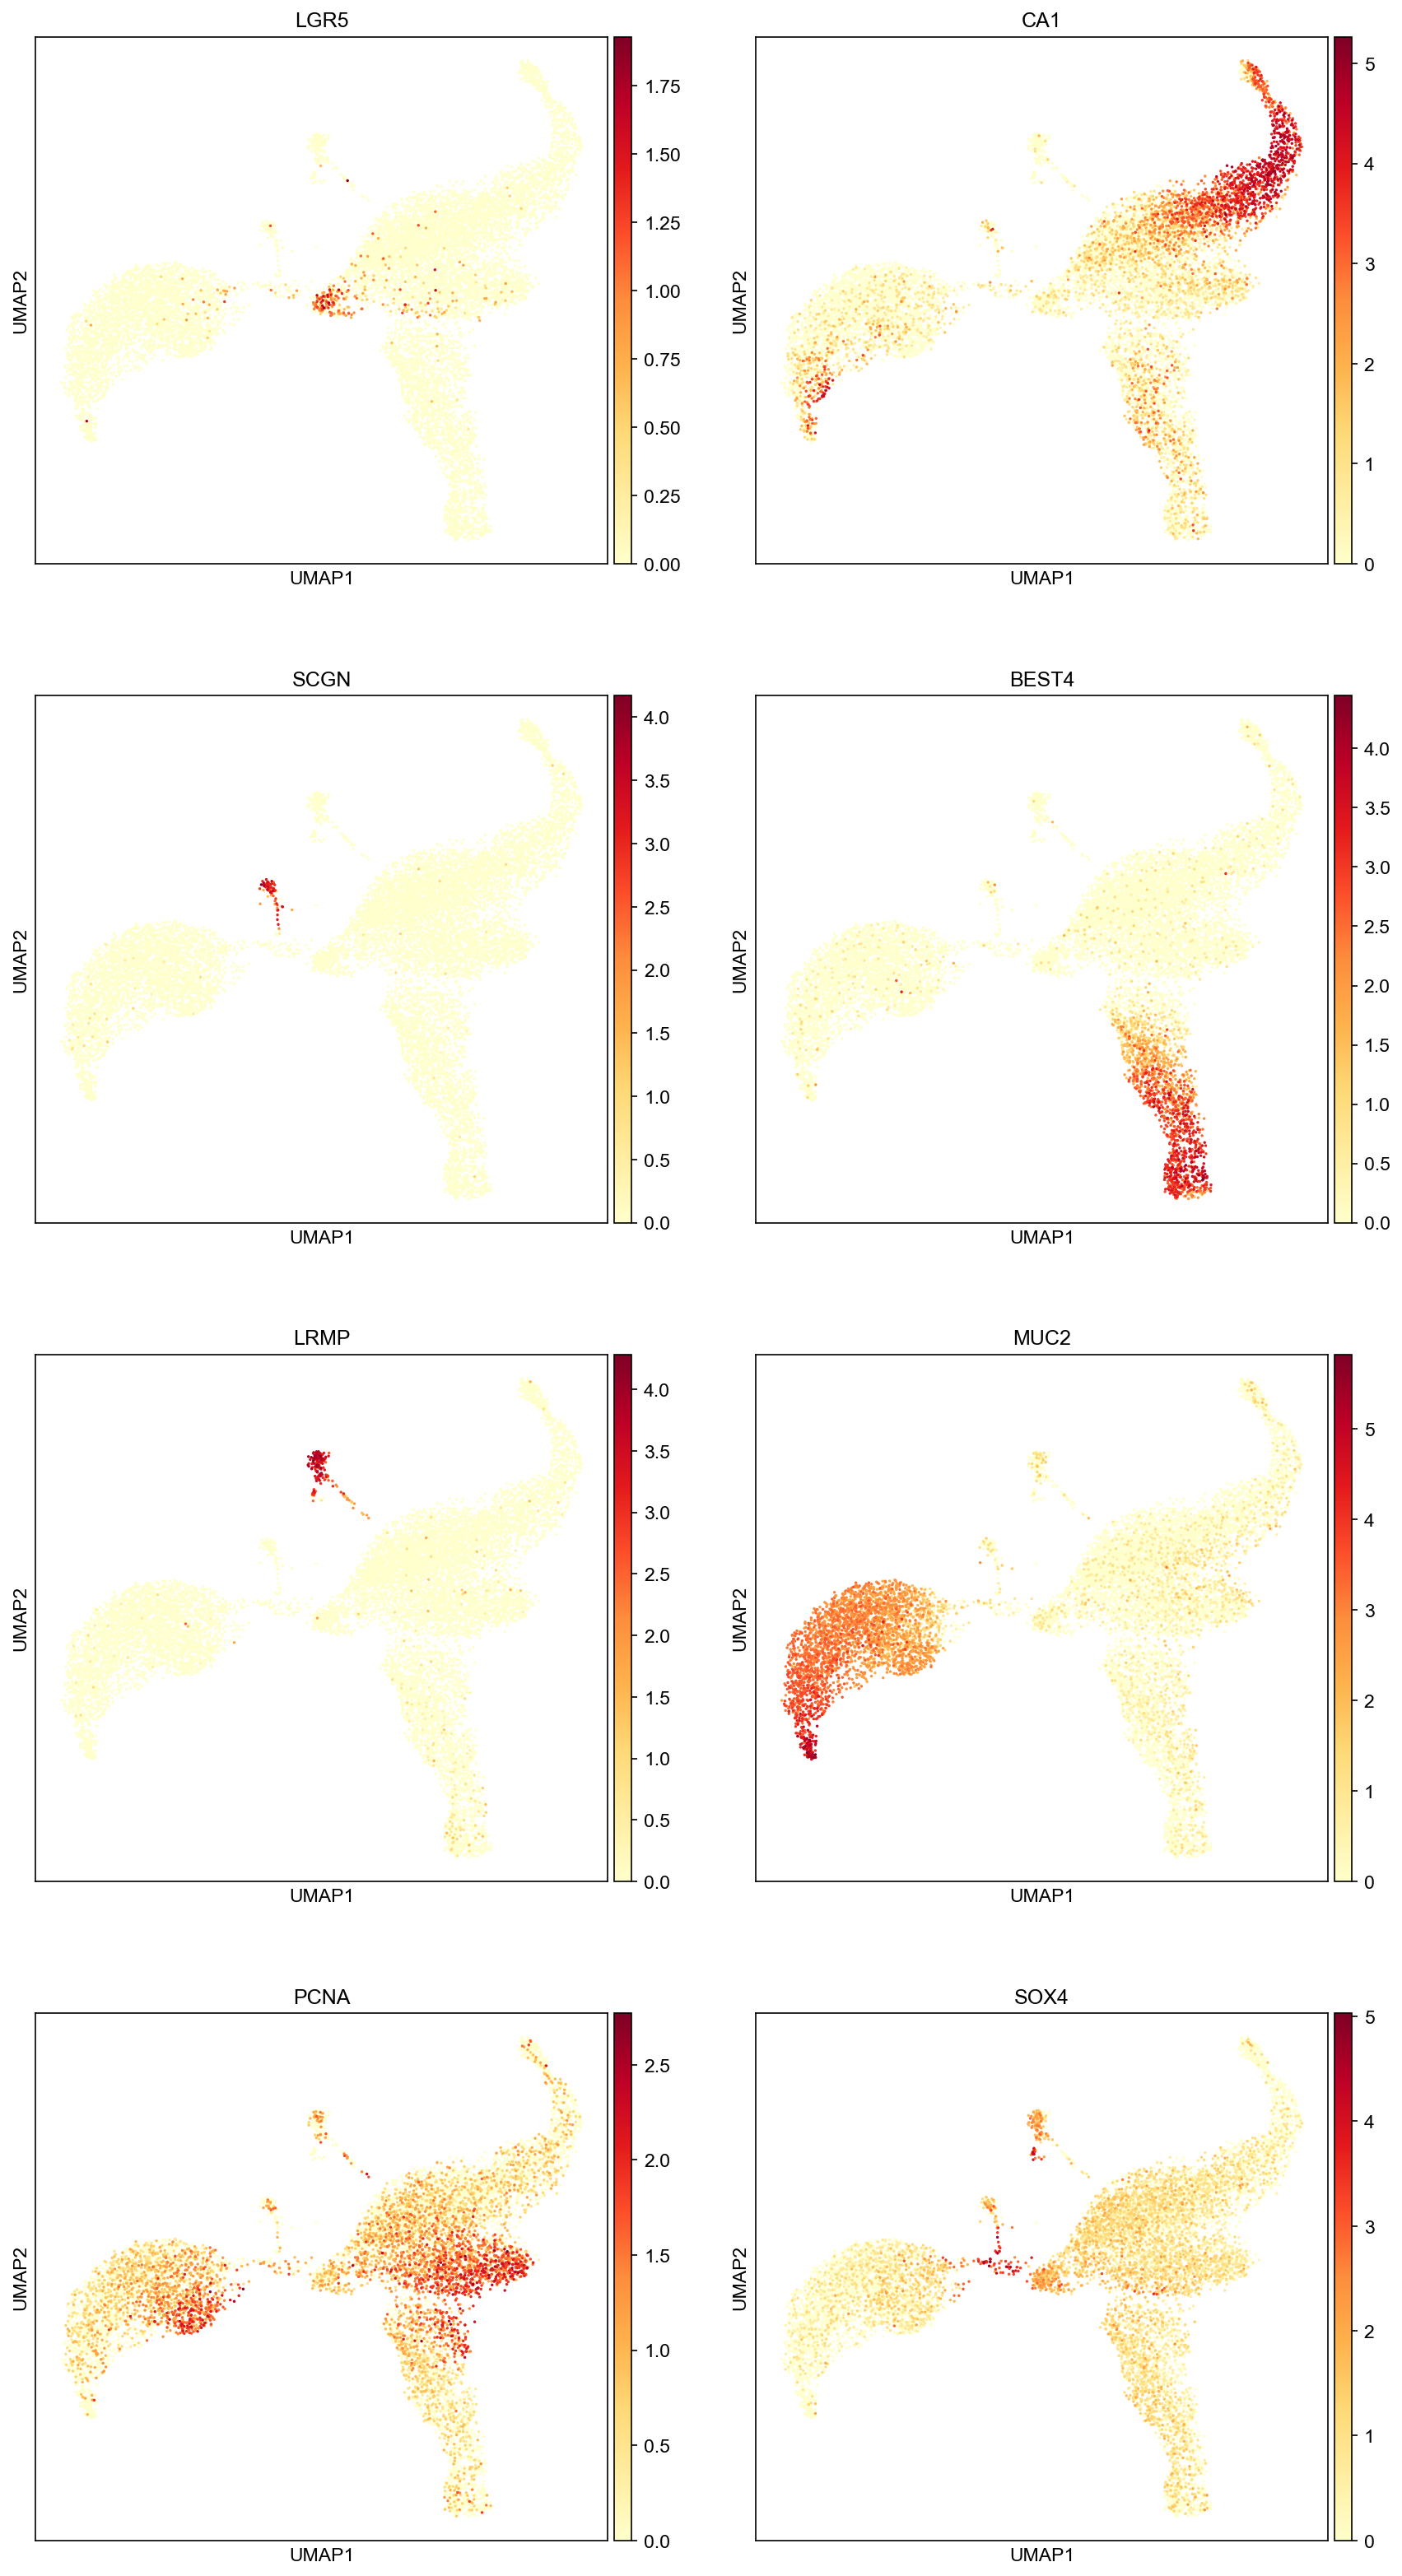

In [9]:
features = ['LGR5', 'CA1', 'SCGN', 'BEST4', 'LRMP', 'MUC2', 'PCNA', 'SOX4']
sc.pl.umap(adata, color=features, use_raw=True, ncols=2, cmap='YlOrRd')

The above steps are an example of what can be done to analyse your data. In reality it takes a lot of trial and error and you should carefully apply your prior knowledge to any inference made from the analysis. Once you are ready, we can begin to assign the clusters to celltypes.

#### 4. Celltype annotation

Let's start by looking back at the original `leiden` clustering.

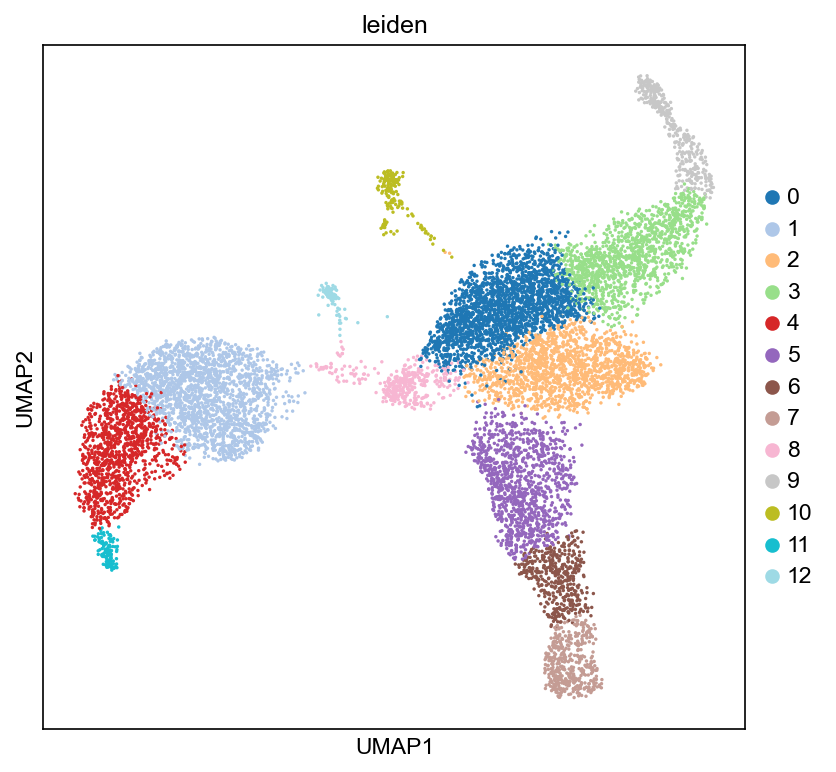

In [10]:
sc.pl.umap(adata, color='leiden', palette='tab20')

If we decide, based on marker expression for instance, that two clusters should be merged, we can easily do it as follows. In this case we want to merge clusters 0 and 2, based on (among others) *PCNA* expression.

In [11]:
adata.obs['leiden'] = adata.obs['leiden'].replace("0", "2")

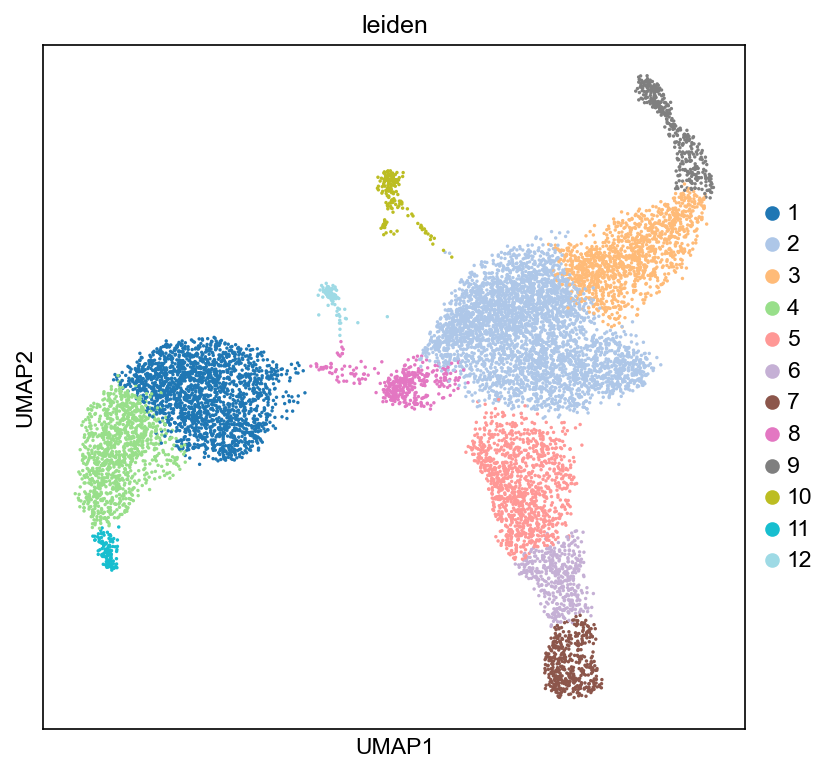

In [12]:
sc.pl.umap(adata, color='leiden', palette='tab20')

On the other hand, you may also want to subdivide certain clusters into more partitions. Here I want to divide the cluster 8 into two based on *SOX4* and *LGR5* expression.

In [13]:
sc.tl.leiden(adata, resolution=0.2, restrict_to=('leiden', ['8']))

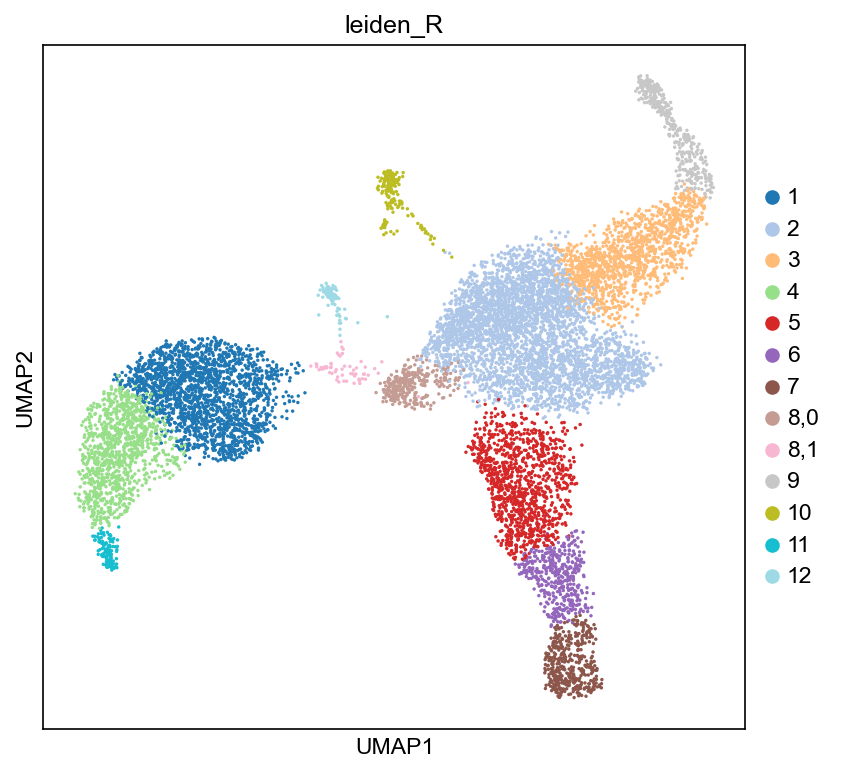

In [14]:
sc.pl.umap(adata, color='leiden_R', palette='tab20')

In this way we get now two clusters, `8,0` and `8,1` which we can assign to different celltypes. Notice that after running `tl.leiden` again, we now have to call the new clustering with `leiden_R`.

Finally, you may have a situation where you need to both divide and merge clusters. In the dataset I am going through this is the case with cluster 5, which based on *PCNA* and *BEST4* expression should be a bit smaller. 

In [15]:
# This time we need to be using leiden_R as clustering since we divided leiden clustering already once before. 
sc.tl.leiden(adata, resolution=0.3, restrict_to=('leiden_R', ['5']))
adata.obs['leiden_R'] = adata.obs['leiden_R'].replace("5,0", "5")
adata.obs['leiden_R'] = adata.obs['leiden_R'].replace("5,1", "6")

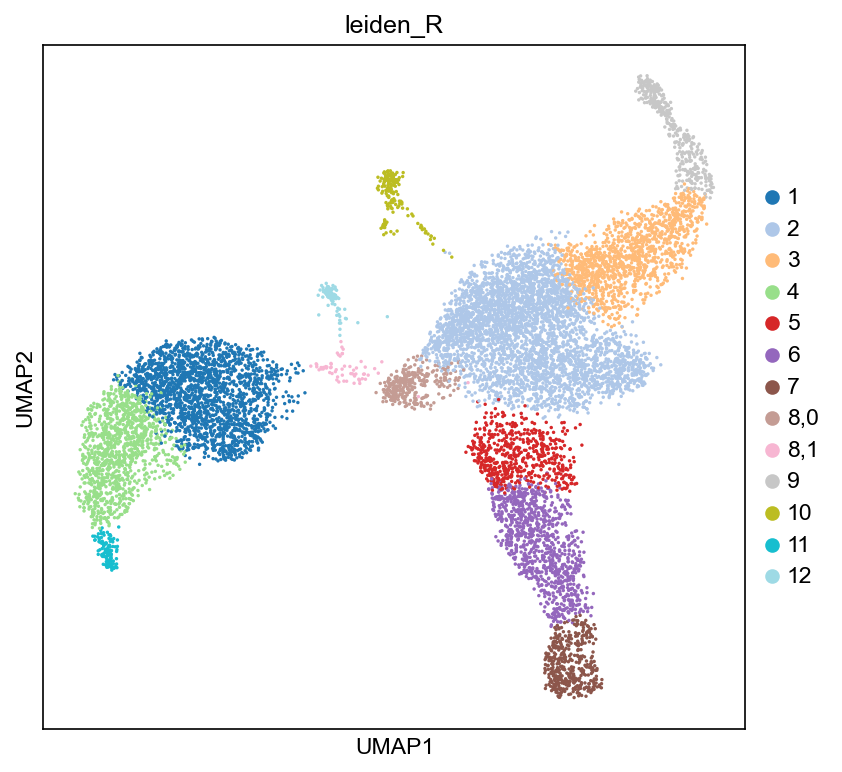

In [16]:
sc.pl.umap(adata, color='leiden_R', palette='tab20')

What's left to do now is to rename the clusters to cell types. To do that we create a new observation annotation and rename the categories.

In [17]:
adata.obs['Celltype'] = adata.obs['leiden_R']
adata.obs['Celltype'] = adata.obs['Celltype'].replace("1", "TA Goblet")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("2", "TA Colonocytes")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("3", "Colonocytes")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("4", "Goblet")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("5", "TA BEST4+")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("6", "BEST4+")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("7", "CT BEST4+")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("8,0", "Stem")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("8,1", "TA SOX4+")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("9", "CT Colonocytes")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("10", "Tuft")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("11", "CT Goblet")
adata.obs['Celltype'] = adata.obs['Celltype'].replace("12", "EECs")

# Reformat the data as category (necessary for plotting).
adata.obs['Celltype'] = adata.obs['Celltype'].astype('category')
Celltype_order = ['Stem',
                  'TA SOX4+',
                  'TA Colonocytes', 'Colonocytes', 'CT Colonocytes',
                  'TA BEST4+', 'BEST4+', 'CT BEST4+', 
                  'TA Goblet', 'Goblet', 'CT Goblet',                  
                  'EECs' ,'Tuft']
# Explicitly assign custom category order for consistency in plots.
adata.obs['Celltype'].cat.reorder_categories(Celltype_order, inplace=True)

It is a good practice to assign custom colours to your grouping variable. That way you can produce consistent, high quality plots from the very begining. 

In [18]:
vega_colors = np.array(sc.pl.palettes.vega_20_scanpy)

celltype_colors = np.zeros(len(set(adata.obs['Celltype'])))
celltype_colors = celltype_colors.astype('U7')

celltype_colors[[0]] =  vega_colors[[1]] # Stem color / orange
celltype_colors[[1]] = '#FFCC00' # TA Goblet SOX4+ colors / yellow
celltype_colors[[2, 3, 4]] = vega_colors[[12, 10, 15]]  # Colono colors / pinks
celltype_colors[[5, 6, 7]] = vega_colors[[0, 8, 17]]  # BEST4 colors / blues
celltype_colors[[8, 9, 10]] = vega_colors[[2, 7, 11]]  # Goblet colors / greens
celltype_colors[[11]] = '#E53333'  # EECs / red
celltype_colors[[12]] = '#A9A9A9'  # Tuft / grey

adata.uns['Celltype_colors'] = celltype_colors

Plot UMAP embedding grouped by Celltype colour coded with the new palette.

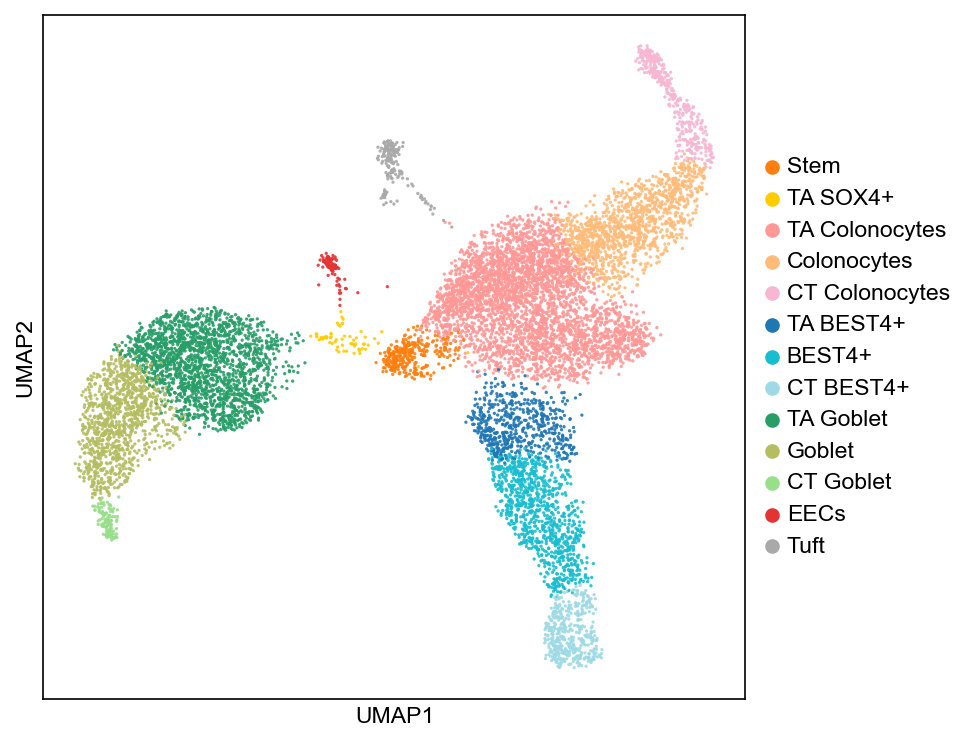

In [19]:
sc.pl.umap(adata, color='Celltype', alpha=0.9, size=10, title='')

We can also now run DEA between the Celltypes.

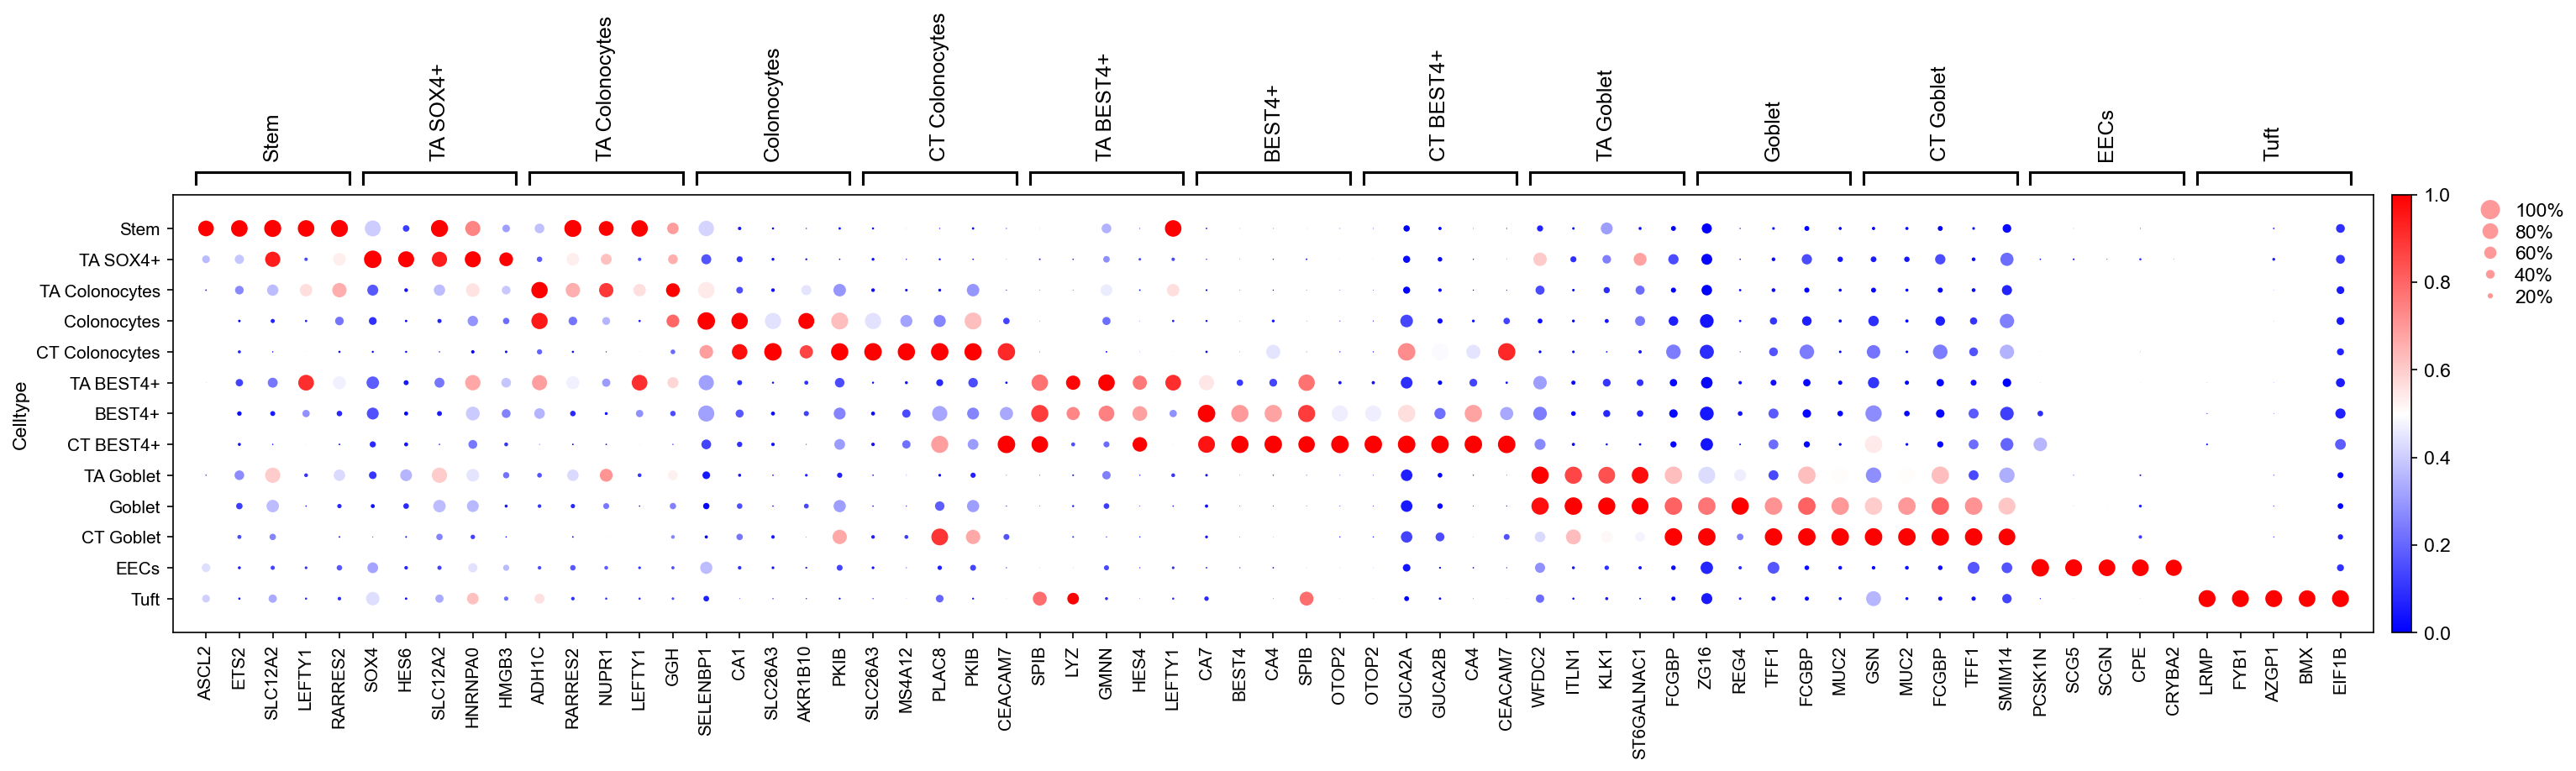

In [20]:
# Rank DEGs per leiden clustering
sc.tl.rank_genes_groups(adata, groupby='Celltype', method='wilcoxon')
# Filter out genes based on expression specificity and fold changen
sc.tl.filter_rank_genes_groups(adata, min_in_group_fraction=0.25, 
                               max_out_group_fraction=0.75, min_fold_change=1.5)
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5, key='rank_genes_groups_filtered', 
                                standard_scale='var', color_map='bwr', dendrogram=False)

#### 5. Trajectory analysis

Before moving on to the RNA velocity analysis in the next part, there is one more common computation we can perfrom on our data, namely the trajectory analysis. This is usually done so that using the patterns in the gene expression change infer the transitions between cell populations. There's an important caveat that those transitions won't have directionality, but I will tell more about that later. In the `scanpy`'s toolbox we have PAGA, which is a fast and accurate trajectory inference tool. It summarises the connections between neighbouring cells per cluster into a "stick and ball" model. 

In [21]:
sc.tl.paga(adata, groups='Celltype')

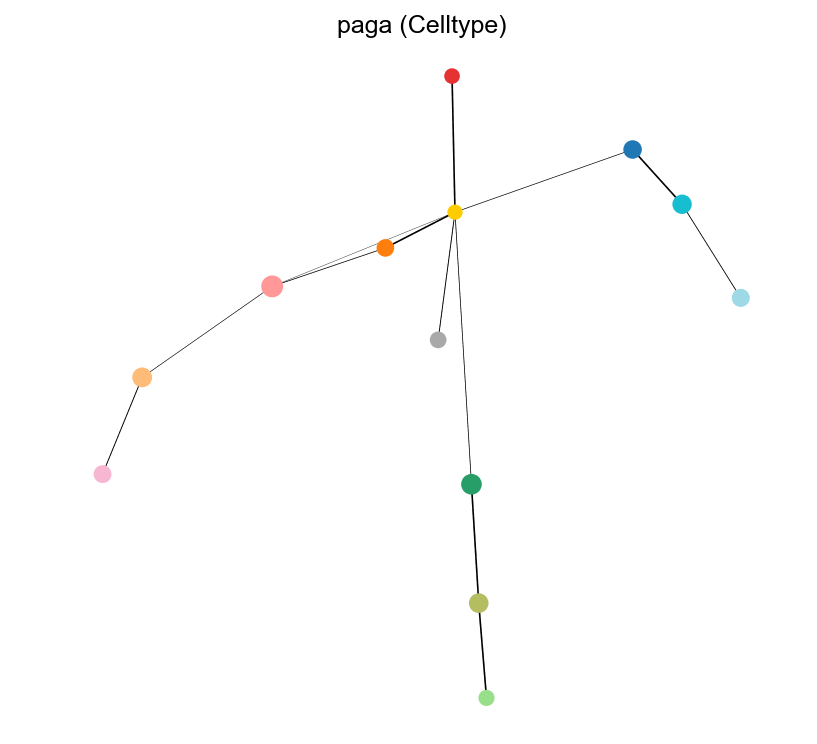

In [22]:
scv.pl.paga(adata, color='Celltype', threshold=0.2, layout='fa',
           node_size_scale=0.4, edge_width_scale=0.1, node_size_power=0.2)

In the PAGA graph above each vertice (ball) represents a celltype (or whatever grouping you run it on). The size of the vertice depends on the number of elements in that group. Edges (sticks) are connectivites. Edges thickness depends on the strength of a connection between two groups. The connection is stronger the more similar the groups are in terms of gene expression. Using the parameter `threshold` while plotting allows us to not draw edges below a certain value.                          

The drawback is that with only 12 points the graph becomes boring an uninformative. An idea is to divide the original grouping (`Celltype` in this case) into smaller clusters and run PAGA on that. However, when plotting we will color by the original grouping to preserve visual clarity. 

In [23]:
adata.obs['SubCelltype'] = adata.obs['Celltype']
for celltype in adata.obs['Celltype'].cat.categories.tolist():
    sc.tl.leiden(adata, resolution=0.69, restrict_to=('SubCelltype', [celltype]), key_added='SubCelltype')

In [24]:
sc.tl.paga(adata, groups='SubCelltype')

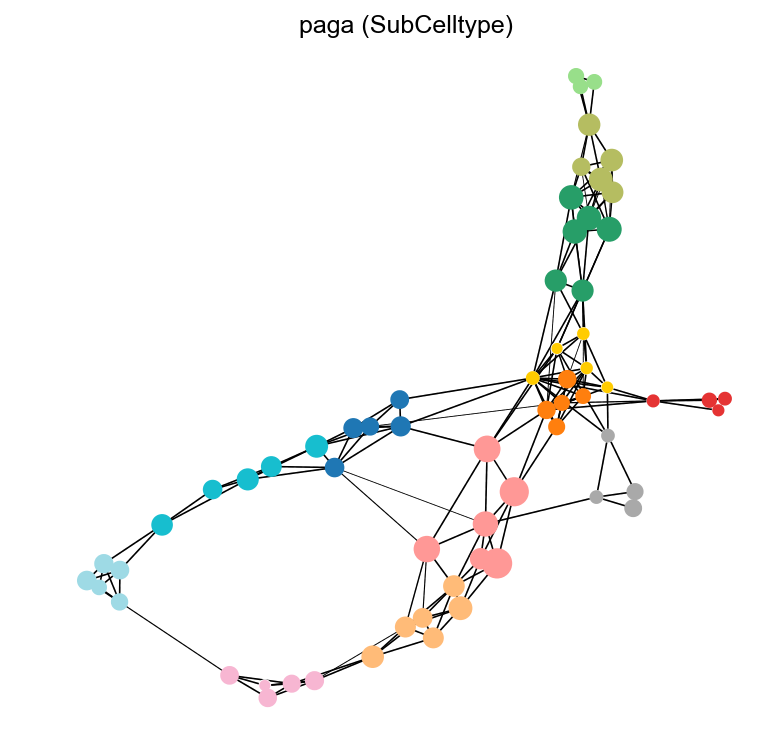

In [25]:
scv.pl.paga(adata, color='Celltype', threshold=0.5, layout='fa',
           node_size_scale=0.4, edge_width_scale=0.1, node_size_power=0.2)

Side note: For plotting PAGA we are using `scVelo`'s plotting function, because the one in `scanpy` got broken in recent updates. You may want to check whether it works in the future. 

By changing the treshold you can adjust the number of connections on the plot, which sometimes changes the look of the graph in a major way (though not in this case).

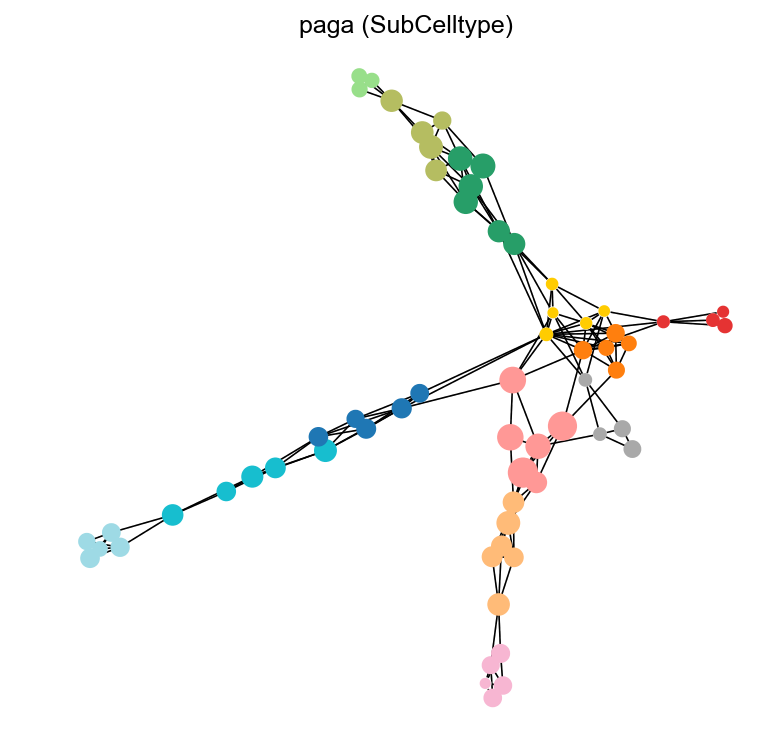

In [26]:
scv.pl.paga(adata, color='Celltype', threshold=1, layout='fa',
           node_size_scale=0.4, edge_width_scale=0.1, node_size_power=0.2)

PAGA plots can be an alternative, simple way to show gene expression.

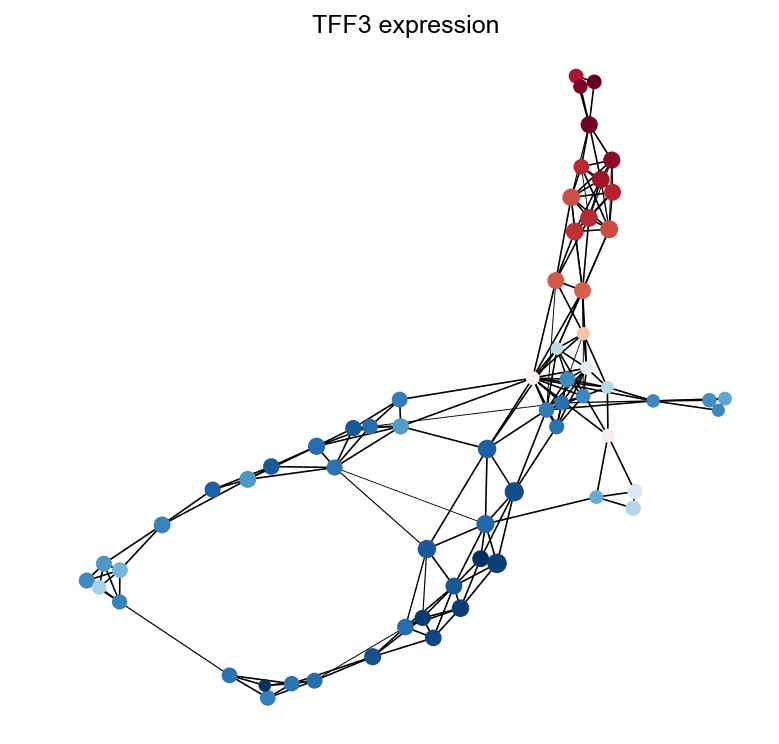

In [27]:
scv.pl.paga(adata, color='TFF3', threshold=0.5, layout='fa', title='TFF3 expression',
           node_size_scale=0.4, edge_width_scale=0.1, node_size_power=0.2)

Or any other observation variable

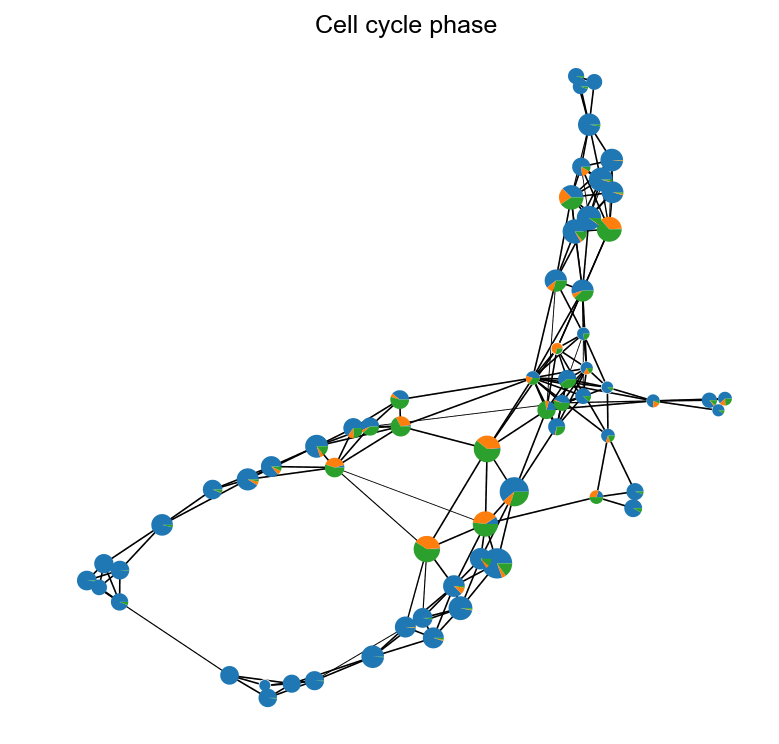

In [28]:
scv.pl.paga(adata, color='phase', threshold=0.5, layout='fa', title='Cell cycle phase',
           node_size_scale=0.4, edge_width_scale=0.1, node_size_power=0.2)

#### 6. Graph embedding based on PAGA

`scanpy` gives you also a possibility of re-drawing the single cell embedding with the PAGA graph as a starting point for the cells. You may want use this representation if you want to accentuate the trajectories without loosing the single cell resolution. By using `edges=True` parameter when plotting you can also visualise the connections between the cells (the neighbourhood we were calculating in previous notebooks).

In [29]:
sc.tl.draw_graph(adata, init_pos='paga')

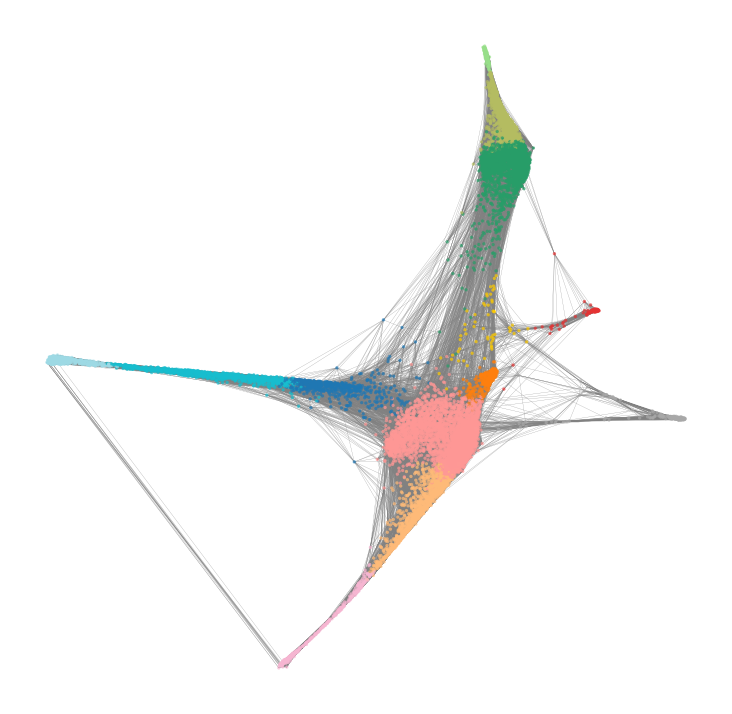

In [30]:
sc.pl.draw_graph(adata, color='Celltype', title='',
                 size=10, alpha=0.7, legend_fontsize=6, frameon=False, edges=True, legend_loc='none')

#### 7. Pseudotime

Trajectory analysis is often combined with pseudotime. Citing "Current best practices in single‐cell RNA‐seq analysis: a tutorial" by Fabian Theis:

"*Trajectory inference methods interpret single‐cell data as a snapshot of a continuous process. This process is reconstructed by finding paths through cellular space that minimize transcriptional changes between neighbouring cells (...) The ordering of cells along these paths is described by a pseudotime variable. While this variable is related to transcriptional distances from a root cell, it is often interpreted as a proxy for developmental time.*"

While certainly useful, pseudotime has an inherent bias in being dependent on the user's choice of starting point. As the choice should be based on known biology of the sample, it limits the amount of new information that could be inferred. 

In [31]:
# Set one of the stem cells as the starting point for the pseudotime.
adata.uns['iroot'] = np.flatnonzero(adata.obs['Celltype']  == 'Stem')[0]

# Calcualte the diffusion map and infer progression of cells through geodesic distance along the graph.
sc.tl.diffmap(adata)
sc.tl.dpt(adata)

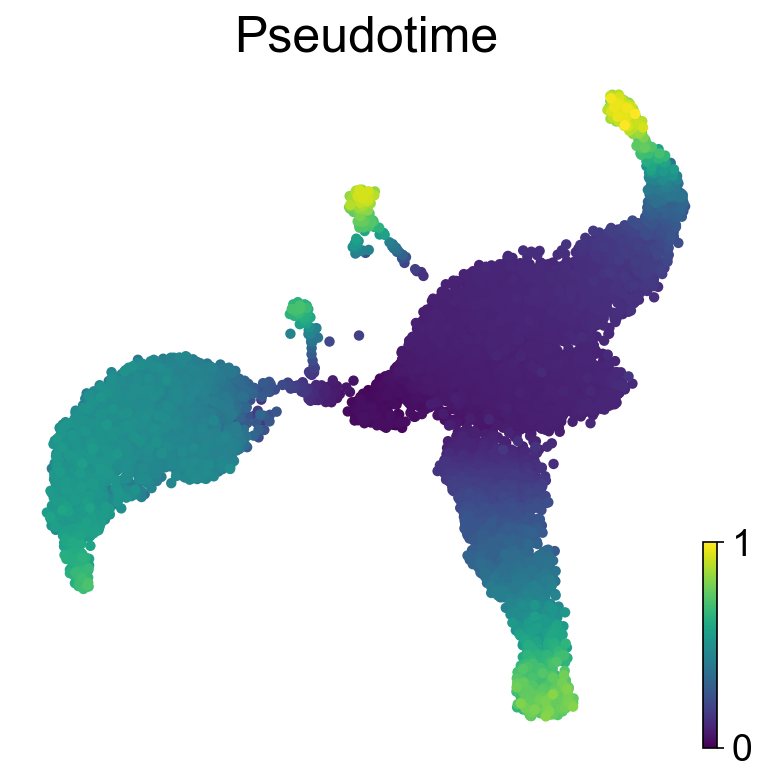

In [32]:
scv.pl.scatter(adata, color='dpt_pseudotime', 
                 size=100, fontsize=24, frameon=False, 
                 cmap='viridis', title='Pseudotime')

#### 8. Save data for the next step 

In [33]:
adata.write("healthy_de.h5ad")